# Imports

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

import glob # collect all images
from PIL import Image # get width/height
import numpy as np

In [2]:
data_dir = "C:\DevOps_tools(Ubuntu_Linux_VM_with_all_tools_installed)\weather dataset\weather image recognition\weather data"

image_paths = glob.glob(data_dir + "/*/*")  # all images in all folders

print("Total images:", len(image_paths))

Total images: 6862


# Augmentation

In [3]:
# compute image sizes

widths = []
heights = []

for path in image_paths:
    try:
        with Image.open(path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except:
        continue  # skip corrupted images

In [4]:
print("Average width:", np.mean(widths))
print("Average height:", np.mean(heights))

print("Min width:", np.min(widths))
print("Min height:", np.min(heights))

print("Max width:", np.max(widths))
print("Max height:", np.max(heights))

Average width: 520.0297289419995
Average height: 373.8417371028855
Min width: 117
Min height: 91
Max width: 4863
Max height: 3174


In [5]:
IMG_SIZE    = (300, 300) # define image size and batch size
BATCH_SIZE  = 32
EPOCHS_HEAD = 20

In [6]:
train_aug = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1, # Helps model generalize better
    horizontal_flip=True, # we are not doing vertical cause the rain and snow does not fall upside down
    brightness_range=[0.8, 1.2], # for the lightes that are so bright
    validation_split=0.2 # to extract a part for validation
    )

val_aug = ImageDataGenerator(validation_split=0.2)


In [7]:
# splitting data 

train_batch = train_aug.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_batch = val_aug.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical', 
    subset='validation'
)

Found 5493 images belonging to 11 classes.
Found 1369 images belonging to 11 classes.


In [8]:
print(train_batch.class_indices)
print(train_batch.classes)

{'dew': 0, 'fogsmog': 1, 'frost': 2, 'glaze': 3, 'hail': 4, 'lightning': 5, 'rain': 6, 'rainbow': 7, 'rime': 8, 'sandstorm': 9, 'snow': 10}
[ 0  0  0 ... 10 10 10]


In [9]:
# Checking the number of each class

counts = np.bincount(train_batch.classes)

for class_name, idx in train_batch.class_indices.items():
    print(class_name, counts[idx])

dew 559
fogsmog 681
frost 380
glaze 512
hail 473
lightning 302
rain 421
rainbow 186
rime 928
sandstorm 554
snow 497


In [10]:
# Balancing class weights

from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_batch.classes),
    y=train_batch.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.8933159863392421), 1: np.float64(0.7332799359231077), 2: np.float64(1.3141148325358851), 3: np.float64(0.9753196022727273), 4: np.float64(1.055737074764559), 5: np.float64(1.6535219747140277), 6: np.float64(1.186136903476571), 7: np.float64(2.6847507331378297), 8: np.float64(0.5381073667711599), 9: np.float64(0.9013784049885133), 10: np.float64(1.004755807572709)}


# Building the Model


In [11]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(300, 300, 3)
)
base_model.trainable = False   # freeze all base layers

In [12]:
# Add classification head

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)   # better than Flatten for EfficientNet
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(11, activation='softmax')(x)
 
model = models.Model(inputs=base_model.input, outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 300, 300,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 300, 300,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        512 │ block1a_se_excit

 Total params: 4,416,942 (16.85 MB)

 Trainable params: 364,811 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)
 
checkpoint = ModelCheckpoint(
    "weather_best.keras",
    monitor='val_accuracy',
    save_best_only=True
)

In [15]:
import os
from tensorflow.keras.models import load_model

if os.path.exists("weather_best.keras"):
    model = load_model("weather_best.keras")
    print("Model loaded from disk!")
    
else:

    # Train Head 
    print("\n>>> Phase 1: Training classification head (base frozen)")
    history_phase1 = model.fit(
        train_batch,
        validation_data=val_batch,
        epochs=EPOCHS_HEAD,
        callbacks=[early_stopping, checkpoint],
        class_weight=class_weights
    )
    
    # Evaluate 
    loss, acc = model.evaluate(val_batch)
    print(f"\nPhase 1 — Val Loss: {loss:.4f} | Val Accuracy: {acc:.4f}")

Model loaded from disk!


In [16]:
# Final Evaluation 

loss, acc = model.evaluate(val_batch)

if 'history_phase1' in dir():
    train_acc_phase1 = history_phase1.history['accuracy'][-1]
    val_acc_phase1   = history_phase1.history['val_accuracy'][-1]
    print(f"Phase 1 — Train Accuracy: {train_acc_phase1:.4f} | Val Accuracy: {val_acc_phase1:.4f}")
else:
    print("Model was loaded from disk — no training history available.")


print(f"\nFinal Evaluation — Val Loss: {loss:.4f} | Val Accuracy: {acc:.4f}")

43/43 ━━━━━━━━━━━━━━━━━━━━ 20s 417ms/step - accuracy: 0.8977 - loss: 0.3303
Model was loaded from disk — no training history available.

Final Evaluation — Val Loss: 0.3303 | Val Accuracy: 0.8977


# Testing 

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 889ms/step


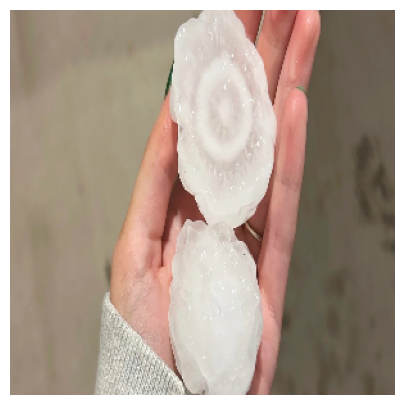

Prediction : hail
Confidence : 99.63%


In [17]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

img_path = r"C:\Users\Admin\Downloads\240314-gorilla-hail-mb-0740-fd878b.webp"

# Load and preprocess
img       = image.load_img(img_path, target_size=(300, 300))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# Predict
prediction      = model.predict(img_array)
class_names     = list(train_batch.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]
confidence      = np.max(prediction) * 100

# Display
plt.figure(figsize=(5, 5))
plt.imshow(img)      
plt.axis('off')
plt.show()

print(f"Prediction : {predicted_class}")
print(f"Confidence : {confidence:.2f}%")

In [18]:
#pip install ipywidgets

In [20]:
from flask_app import app

app.run(port=5000, debug=False, use_reloader=False)

 * Serving Flask app 'flask_app'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [04/May/2026 13:11:29] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [04/May/2026 13:11:36] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [04/May/2026 13:12:01] "POST /predict HTTP/1.1" 200 -
127.0.0.1 - - [04/May/2026 13:12:34] "POST /predict HTTP/1.1" 200 -
